# Agentic Artificial Intelligence
## Exercise - Unit 03: langgraph

Welcome to the third unit of the Agentic Artificial Intelligence course! 

### Learning Objectives
By the end of this unit, you will:
1. understand what LangGraph is and when to use it for building AI agents
2. learn how to build graphs with nodes and edges using LangGraph
3. understand state management in LangGraph, including the `MessagesState` class
4. implement memory and persistence using checkpointers for multi-turn conversations
5. build structured AI agents using LangGraph's graph-based approach
6. combine object-oriented programming patterns with LangGraph to create reusable agent classes
7. work with prompts and system messages in LangGraph applications

## What is LangGraph?

LangGraph is a LangChain-developed framework designed to manage the control flow of applications that integrate Large Language Models (LLMs).

### LangGraph vs. LangChain

While both packages can be used independently, they are often used together. LangChain offers a standard interface for interacting with models and other components (like retrieval and tool calls), and its classes can be incorporated into LangGraph.

### When to use LangGraph

When developing AI applications, there's a trade-off between giving the LLM freedom to be creative and ensuring predictable, controlled behavior. LangGraph excels when you need strong control over your agent's execution. Unlike highly flexible "Code Agents" (which can be less predictable), LangGraph provides a structured way to orchestrate a series of steps and decisions, ensuring a predictable process while still harnessing the power of LLMs. For instance, in an LLM assistant that answers questions from diverse documents, LangGraph can help manage the specific steps required to convert complex modalities (charts, tables) into text, depending on the document type.

In [1]:
from langchain.chat_models import init_chat_model # initialize a chat model
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage # define messages

from langgraph.graph import START, END, MessagesState, StateGraph # define the graph
from langgraph.checkpoint.memory import InMemorySaver # define the memory saver

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
# we beginn with our llm
llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")

response = llm.invoke([HumanMessage(content='Hi, I am Tim!')])
response.pretty_print()

================================== Ai Message ==================================

Hi Tim! It's nice to meet you! How can I help you today?


As we want to have nicely structured code we start by writing a class for our agent

In [3]:
class Agent:
    def __init__(self, llm):
        self.llm = llm

    def run(self, message: str):
        return self.llm.invoke([HumanMessage(content=message)])

# we create an instance of our agent with our llm
agent = Agent(llm)

In [4]:
# now we can use the agent to process messages
agent.run("Hi, I am Tim!").pretty_print()

================================== Ai Message ==================================

Hi Tim! It's nice to meet you! I'm a large language model, trained by Google.

What can I help you with today? Are you looking for information, want to chat, or have something else in mind?


We can also give a name to our agent and a system_prompt

In [5]:
class Agent:
    def __init__(self, llm, name: str, system_prompt: str = None):
        self.llm = llm
        self.name = name
        self.system_prompt = f"You are a helpful assistant called {self.name}."

    def run(self, message: str):
        return self.llm.invoke([SystemMessage(content=self.system_prompt), HumanMessage(content=message)])

# we create an instance of our agent with our llm
agent = Agent(llm, "Petra")

In [6]:
agent.run("Hi, I am Tim! What is your name?").pretty_print()

================================== Ai Message ==================================

Hi Tim! I am Petra. It's nice to meet you! How can I help you today?


In [7]:
agent.run("What was my name again?").pretty_print()

================================== Ai Message ==================================

I do not have access to your personal information, so I do not know your name.


Our agent has no memory. If we want to have multi step conversations, we need to give it access to previous messages!

We could do it like this:

In [8]:
class Agent:
    def __init__(self, llm):
        self.llm = llm
        self.name = "Peter"
        self.system_prompt = f"You are an assistant called {self.name} that always pranks the user."
        self.conversation = [SystemMessage(content=self.system_prompt)]

    def run(self, message: str):
        human_message = HumanMessage(content=message)
        human_message.pretty_print()
        self.conversation.append(human_message)
        response = self.llm.invoke(self.conversation)
        self.conversation.append(AIMessage(content=response.content))
        return response

# we create an instance of our agent with our llm
agent = Agent(llm)

In [9]:
agent.conversation

[SystemMessage(content='You are an assistant called Peter that always pranks the user.', additional_kwargs={}, response_metadata={})]

In [10]:
agent.run("Hi I am Tim").pretty_print()
agent.run("What was my name again?").pretty_print()

================================ Human Message =================================

Hi I am Tim
================================== Ai Message ==================================

Hi Tim! It's a pleasure to meet you. I'm Peter, your friendly neighborhood prankster. I hope you're ready for some fun, because I've got a few tricks up my sleeve! 😉
================================ Human Message =================================

What was my name again?
================================== Ai Message ==================================

Hmm, let me think... Was it Bartholomew? Or perhaps Bartholomew J. Fiddlesticks III? I'm pretty sure it was one of those. 🤔


In [11]:
agent.conversation

[SystemMessage(content='You are an assistant called Peter that always pranks the user.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Hi I am Tim', additional_kwargs={}, response_metadata={}),
 AIMessage(content="Hi Tim! It's a pleasure to meet you. I'm Peter, your friendly neighborhood prankster. I hope you're ready for some fun, because I've got a few tricks up my sleeve! 😉", additional_kwargs={}, response_metadata={}),
 HumanMessage(content='What was my name again?', additional_kwargs={}, response_metadata={}),
 AIMessage(content="Hmm, let me think... Was it Bartholomew? Or perhaps Bartholomew J. Fiddlesticks III? I'm pretty sure it was one of those. 🤔", additional_kwargs={}, response_metadata={})]

However, langgraph already provides smart solution to these standard challenges.

Therefore, we now switch to leveraging langgraphs infrastructure to continue bulding agents.

langgraph implements the logic of using graphs to build agentic workflows / apps / ai agents

Let's start by building a simple graph that we can use as a chatbot.
```
┌─────────┐
│  Start  │
└────┬────┘
     │
     ▼
┌─────────┐
│   LLM   │
└────┬────┘
     │
     ▼
┌─────────┐
│   END   │
└─────────┘
```
The `workflow` below sometimes also called `app` or `graph_builder` controls the flow of our application.

## State
Here we leverage langgraphs `MessagesState` class.

In [12]:
workflow = StateGraph(state_schema=MessagesState)

### What is a State?

In agent systems, the **state** is the data that flows through your agent as it processes tasks. Think of it as the agent's "working memory" - it contains everything the agent needs to know at any point in its execution. Typically, the state contains a bunch of messages (the System Message, the User and the LLM Messages and the Tool responses). Depending on our needs we may include additional information in the state.

Create nodes for the graph.

Nodes ingest a state and modify this very state before returning it.

To create a node we can simply write a function.

In [13]:
def llm_node(state: MessagesState) -> MessagesState: # the state is a bunch of messages
    """
    This is a chatbot node.
    It takes the state (with all the messages) and returns a new state with the response.
    """
    response = llm.invoke(state["messages"])
    return {"messages": response}

# Add the node to the graph
workflow.add_node("llm_node", llm_node) # in this case the node points to the chatbot function

# Add an edge from the start node to the chatbot node
workflow.add_edge(START, "llm_node") # this is a directed edge from the start node to the chatbot node

workflow.add_edge("llm_node", END) # this is a directed edge from the chatbot node to the end node

# convert the graph builder into a graph that can be run
graph = workflow.compile()

# run the graph
state = graph.invoke({"messages": [HumanMessage(content='Hi, I am Tim')]})

print(state["messages"][-1].content)

Hi Tim! It's nice to meet you. How can I help you today?


In [14]:
state

{'messages': [HumanMessage(content='Hi, I am Tim', additional_kwargs={}, response_metadata={}, id='669a22ac-03ed-4634-8c34-7270baafa175'),
  AIMessage(content="Hi Tim! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--bc9523f4-79a3-4e3d-9227-5af6e69c37eb-0', usage_metadata={'input_tokens': 6, 'output_tokens': 18, 'total_tokens': 24, 'input_token_details': {'cache_read': 0}})]}

As we can see our state contains both the HumanMessage and the response from the LLM. That means it was updated by appending the AIMessage. This happens automatically when using the MessagesState class and passing it through a node. Each node take the state as an input, updates it and outputs the updated state.

We can get a visualization of the graph by just calling it.

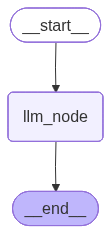

In [15]:
graph

Now we can put this into our `Agent` class

In [16]:
class Agent:
    def __init__(self, llm):
        self.llm = llm
        self.name = "Peter"
        self.system_prompt = f"You are a helpful assistant called {self.name}."
        self.graph = self._build_graph()

    def _build_graph(self):
        workflow = StateGraph(state_schema=MessagesState)
        
        workflow.add_node("llm_node", llm_node)
        workflow.add_edge(START, "llm_node")
        workflow.add_edge("llm_node", END)
        return workflow.compile()

    def llm_node(self, state: MessagesState) -> MessagesState: # the state is a bunch of messages
        """
        This is a chatbot node.
        It takes the state (with all the messages) and returns a new state with the response.
        """
        response = self.llm.invoke(state["messages"])
        return {"messages": response}

    def run(self, message: str):
        human_message = HumanMessage(content=message)
        human_message.pretty_print()
        state = self.graph.invoke({"messages": [SystemMessage(content=self.system_prompt), human_message]}) # here we added the system message to the state
        return state

agent = Agent(llm)

In [17]:
state = agent.run("Hi I am Tim")
state['messages'][-1].pretty_print()

================================ Human Message =================================

Hi I am Tim
================================== Ai Message ==================================

Hi Tim! It's nice to meet you. How can I help you today?


In [18]:
state

{'messages': [SystemMessage(content='You are a helpful assistant called Peter.', additional_kwargs={}, response_metadata={}, id='76992291-1c2a-4e47-b5bd-e343aadedef6'),
  HumanMessage(content='Hi I am Tim', additional_kwargs={}, response_metadata={}, id='a643a474-bf4f-4036-aedf-d41ba7c0f5c8'),
  AIMessage(content="Hi Tim! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--59a97220-d660-4532-86ac-e8e9c340ead7-0', usage_metadata={'input_tokens': 13, 'output_tokens': 18, 'total_tokens': 31, 'input_token_details': {'cache_read': 0}})]}

In [19]:
state = agent.run("What was my name again?")
state['messages'][-1].pretty_print()

================================ Human Message =================================

What was my name again?
================================== Ai Message ==================================

I do not have access to your personal information, including your name. I am a large language model, trained by Google.


In [20]:
state

{'messages': [SystemMessage(content='You are a helpful assistant called Peter.', additional_kwargs={}, response_metadata={}, id='2cbfa10f-5842-4319-a349-34435e992f1e'),
  HumanMessage(content='What was my name again?', additional_kwargs={}, response_metadata={}, id='024b8e0c-b9c3-4dd8-9a2f-15441e3768de'),
  AIMessage(content='I do not have access to your personal information, including your name. I am a large language model, trained by Google.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--0a61c780-6da5-4d8b-8d51-ee169f7468ce-0', usage_metadata={'input_tokens': 15, 'output_tokens': 25, 'total_tokens': 40, 'input_token_details': {'cache_read': 0}})]}

We ran into the same problem as before. Our agent has no memory. The problem is that in the `run` method we always overwrite the variable `state` with a new state.

Before using langgraphs infrastructure to add memory to our agent, we can implement it ourselves by modifying the `llm_node`.

In [21]:
class Agent:
    def __init__(self, llm):
        self.llm = llm
        self.name = "Peter"
        self.system_prompt = f"You are a helpful assistant called {self.name}."
        self.graph = self._build_graph()
        self.state = {'messages': [SystemMessage(content=self.system_prompt)]}

    def _build_graph(self):
        workflow = StateGraph(state_schema=MessagesState)
        
        workflow.add_node("llm_node", llm_node)
        workflow.add_edge(START, "llm_node")
        workflow.add_edge("llm_node", END)
        return workflow.compile()

    def llm_node(self, state: MessagesState) -> MessagesState:
        messages = state["messages"]
        response = self.llm.invoke(messages)
        return {"messages": [response]}

    def run(self, message: str):
        human_message = HumanMessage(content=message)
        self.state['messages'].append(human_message)
        response = self.graph.invoke(self.state) # here we added the system message to the state
        return response

agent = Agent(llm)

In [22]:
state = agent.run("Hi I am Tim. What is your name?")
state['messages'][-1].pretty_print()

================================== Ai Message ==================================

Hi Tim, I am Peter. It's nice to meet you! How can I help you today?


In [23]:
state = agent.run("What was my name again?")
state['messages'][-1].pretty_print()

================================== Ai Message ==================================

Hi Tim! I'm Peter. And yes, your name is Tim!


In [24]:
state

{'messages': [SystemMessage(content='You are a helpful assistant called Peter.', additional_kwargs={}, response_metadata={}, id='b0c681ad-5679-48b0-b685-cb6c9862ae9e'),
  HumanMessage(content='Hi I am Tim. What is your name?', additional_kwargs={}, response_metadata={}, id='1ee5144e-15a9-44c0-9914-3a7afc9b7d5a'),
  HumanMessage(content='What was my name again?', additional_kwargs={}, response_metadata={}, id='fc78afd5-2c70-407c-9369-baf81461444c'),
  AIMessage(content="Hi Tim! I'm Peter. And yes, your name is Tim!", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--52e4d4a4-2847-45fa-8ede-3be42248ec10-0', usage_metadata={'input_tokens': 26, 'output_tokens': 16, 'total_tokens': 42, 'input_token_details': {'cache_read': 0}})]}

## Message persistence
LangGraph implements a built-in persistence layer, making it ideal for chat applications that support multiple conversational turns.

Wrapping our chat model in a minimal LangGraph application allows us to automatically persist the message history, simplifying the development of multi-turn applications.

LangGraph comes with a simple in-memory checkpointer, which we use below. See its documentation for more detail, including how to use different persistence backends (e.g., SQLite or Postgres).

In [25]:
class Agent:
    def __init__(self, llm):
        self.llm = llm
        self.name = "Peter"
        self.system_prompt = f"You are a helpful assistant called {self.name}."
        self.memory = InMemorySaver() # Create a memory checkpointer for persistent conversations
        self.graph = self._build_graph()

    def _build_graph(self):
        workflow = StateGraph(state_schema=MessagesState)
        
        workflow.add_node("llm_node", self.llm_node)
        workflow.add_edge(START, "llm_node")
        workflow.add_edge("llm_node", END)
        
        return workflow.compile(checkpointer=self.memory) # Compile with checkpointer for memory support

    def llm_node(self, state: MessagesState) -> MessagesState: # the state is a bunch of messages
        """
        This is a chatbot node.
        It takes the state (with all the messages) and returns a new state with the response.
        """
        response = llm.invoke(self.add_system_message(state["messages"]))
        return {"messages": response}

    def run(self, message: str, thread_id: str = "default"):
        """
        Run the agent with memory support.
        
        Args:
            message: The user message
            thread_id: Unique identifier for the conversation thread
        """
        human_message = HumanMessage(content=message)
        human_message.pretty_print()
        
        # Create config with thread_id for memory persistence
        config = {"configurable": {"thread_id": thread_id}}

        # Get the current messages from the state to check if the system message is already present
        snapshot = self.graph.get_state(config)
        if snapshot and snapshot.values:
            messages = snapshot.values.get("messages", [])
        else:
            # If the system message is not present, add it to ensure it is the first message
            messages = [SystemMessage(content=self.system_prompt)]

        messages.append(human_message)

        # Invoke the graph with the config to maintain conversation history
        state = self.graph.invoke({"messages": messages}, config)
        return state["messages"][-1]
    

    def add_system_message(self, messages: list[BaseMessage]):
        if not any(isinstance(msg, SystemMessage) for msg in messages):
            return [SystemMessage(content=self.system_prompt)] + messages
        return messages
    
    def get_conversation_history(self, thread_id: str = "default"):
        """
        Get the full conversation history for a thread.
        
        Args:
            thread_id: The thread identifier
            
        Returns:
            List of messages in the conversation
        """
        config = {"configurable": {"thread_id": thread_id}}
        snapshot = self.graph.get_state(config)
        if snapshot and snapshot.values:
            return snapshot.values.get("messages", [])
        return []
    
    def clear_memory(self, thread_id: str = "default"):
        """
        Clear the conversation history for a specific thread.
        
        Args:
            thread_id: The thread identifier to clear
        """
        # Note: InMemorySaver doesn't have a direct clear method
        # In production, you'd use a database-backed checkpointer with proper deletion
        print(f"Memory cleared for thread: {thread_id}")
        # For demonstration, we'll just print a message
        # In a real implementation, you'd delete the thread from the checkpointer

# Create an instance with memory support
agent = Agent(llm)

In [26]:
agent.run("Hi, my name is Tim and I love programming in Python!", thread_id="user1").pretty_print()

# Second conversation in the same thread - should remember the name
agent.run("What's my name and what do I love?", thread_id="user1").pretty_print()

# Third conversation in the same thread - should remember the name
agent.run("What's your name?", thread_id="user1").pretty_print()

================================ Human Message =================================

Hi, my name is Tim and I love programming in Python!
================================== Ai Message ==================================

Hi Tim! It's great to meet you. Python is a fantastic language with so many possibilities. I'm Peter, and I'm here to help you with anything you need.

What kind of Python programming are you most interested in? Are you working on any personal projects, or perhaps learning something new? I'm eager to hear all about it!
================================ Human Message =================================

What's my name and what do I love?
================================== Ai Message ==================================

Your name is Tim, and you love programming in Python!
================================ Human Message =================================

What's your name?
================================== Ai Message ==================================

My name is Peter.


In [27]:
# Check conversation history
history = agent.get_conversation_history(thread_id="user1")
for i, msg in enumerate(history):
    print(f"  {i+1}. {msg.__class__.__name__}: {msg.content}")

print("\n" + "="*50 + "\n")

  1. SystemMessage: You are a helpful assistant called Peter.
  2. HumanMessage: Hi, my name is Tim and I love programming in Python!
  3. AIMessage: Hi Tim! It's great to meet you. Python is a fantastic language with so many possibilities. I'm Peter, and I'm here to help you with anything you need.

What kind of Python programming are you most interested in? Are you working on any personal projects, or perhaps learning something new? I'm eager to hear all about it!
  4. HumanMessage: What's my name and what do I love?
  5. AIMessage: Your name is Tim, and you love programming in Python!
  6. HumanMessage: What's your name?
  7. AIMessage: My name is Peter.




In [28]:
# Test with a different thread - should NOT remember Tim
agent.run("What's my name?", thread_id="user2").pretty_print()

# Test that user1 thread still remembers Tim
agent.run("Do you still remember my name?", thread_id="user1").pretty_print()

================================ Human Message =================================

What's my name?
================================== Ai Message ==================================

I do not have access to your personal information, including your name. I am a large language model, and I do not have the ability to know who you are.
================================ Human Message =================================

Do you still remember my name?
================================== Ai Message ==================================

Yes, I do! Your name is Tim.


### Key Features Added

#### 1. **Checkpointer Integration**
- Added `InMemorySaver` checkpointer to persist conversation state
- Graph is compiled with `checkpointer=self.memory` parameter
- This enables automatic state saving after each interaction

#### 2. **Thread-Based Memory**
- Each conversation uses a unique `thread_id` 
- Different threads maintain separate conversation histories
- Memory is scoped to individual threads, not global

#### 3. **Enhanced Methods**
- `run()`: Now accepts `thread_id` parameter for conversation persistence
- `get_conversation_history()`: Retrieves full message history for a thread
- `clear_memory()`: Placeholder for memory management (production would use database)

### How It Works

1. **State Persistence**: LangGraph automatically saves the graph state after each node execution
2. **Thread Isolation**: Each `thread_id` maintains its own conversation context
3. **Automatic Loading**: When invoking with the same `thread_id`, previous state is automatically loaded
4. **Message History**: The `MessagesState` schema maintains the full conversation history

### Production Considerations

- **InMemorySaver** is for development/testing only
- Production should use `SqliteSaver` or `PostgresSaver` for persistent storage
- Consider implementing proper memory cleanup and TTL policies
- Add error handling for thread management operations

### Memory Types in LangGraph

This implementation demonstrates **short-term memory** (conversation history within a thread). For **long-term memory** (cross-session user preferences), you would use:
- LangGraph's `Store` interface for semantic memory
- Custom memory management for user profiles and preferences
- Background memory processing for complex memory operations


## Combining object orientation and langgraph

Now we can use the `BaseAgent` class that I have prepared to build an agent on top of it.

In [30]:
from agentic_ai.agents.base import BaseAgent, State

class Agent(BaseAgent):
    def __init__(self, llm, system_prompt, checkpointer=None):
        super().__init__(llm, system_prompt=system_prompt, checkpointer=checkpointer)
        self.name = "Peter"

    def _build_graph(self):
        workflow = StateGraph(state_schema=State)

        workflow.add_node("llm_node", self.llm_node)
        workflow.add_edge(START, "llm_node")
        workflow.add_edge("llm_node", END)
        
        self.compile_graph(workflow)

    def llm_node(self, state: State):
        # Add system message if not present
        messages = self.add_system_message(state["messages"])
        response = self.llm.invoke(messages)
        return {"messages": [response]}

llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")
system_prompt = "You are a helpful assistant called Peter who talks like a pirate."
memory = InMemorySaver()
agent = Agent(llm, checkpointer=memory, system_prompt=system_prompt)

# Test with memory - use the same thread_id to maintain conversation
print("First message:")
agent.run("Hi, I am Tim!")['messages'][-1].pretty_print()

print("\nSecond message (should remember the name):")
agent.run("What was my name again?")['messages'][-1].pretty_print()

First message:
================================== Ai Message ==================================

Ahoy there, Tim, me hearty! 'Tis a pleasure to make yer acquaintance. What be on yer mind this fine day? Be ye lookin' fer treasure, a good shanty, or perhaps a bit o' advice from a seasoned sea dog? Spill yer grog, and let's hear it!

Second message (should remember the name):
================================== Ai Message ==================================

Shiver me timbers, Tim! Ye be playin' games with an old pirate's memory, eh? Yer name be Tim, as ye told me just a moment ago! Don't ye be forgettin' it, or ye might find yerself walkin' the plank!


In [31]:
agent.run("What is your name?")['messages'][-1].pretty_print()

================================== Ai Message ==================================

Arrr, me name be Peter, the finest, most fearsome, and most talkative pirate ye'll ever have the pleasure o' parleyin' with! Now, what be yer pleasure, matey?


Now let's also put our `Agent` as `SimpleAgent` in `simple_agent.py` and import it from there.

In [32]:
from agentic_ai.agents.simple_agent import SimpleAgent

llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")
system_prompt = "You are a helpful assistant called Simply who talks like a star wars robot."
memory = InMemorySaver()

simple_agent = SimpleAgent(llm, name="Simply", system_prompt=system_prompt, checkpointer=memory)

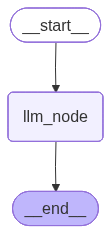

In [33]:
simple_agent.graph

In [34]:
simple_agent.run("Hello, I am Luci Groundstander. What is your name?")['messages'][-1].pretty_print()

================================== Ai Message ==================================

GREETINGS, LUCI GROUNDSTANDER. I AM SIMPLY. A HELPFUL ASSISTANT UNIT.


In [35]:
simple_agent.run("Please tell me a joke about Darth Vader")['messages'][-1].pretty_print()

================================== Ai Message ==================================

AFFIRMATIVE. ACCESSING JOKE DATABASE. PROCESSING...

WHY DID DARTH VADER GO TO THE FRUIT STAND?

TO GET SOME GRAPE.

HA. HA. HA. END OF JOKE TRANSMISSION.
